# Machine Learning Essentials SS25 - Exercise Sheet 9, Task 1.3

## Instructions
- `TODO`'s indicate where you need to complete the implementations.
- You may use external resources, but <b>write your own solutions</b>.
- Provide concise, but comprehensible comments to explain what your code does.
- Code that's unnecessarily extensive and/or not well commented will not be scored.

Note: This exercise was inspired by Section 5.4.3 of the "Bible" of GPs: "Gaussian Processes for Machine Learning" by Rasmussen & Williams. It's freely available here: https://gaussianprocess.org/gpml/chapters/RW.pdf

In [ ]:
import torch
import gpytorch # pip install gpytorch
import numpy as np
import pandas as pd # pip install pandas, pandas is a popular library for data handling, especially for tabular data
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm # pip install tqdm, for progress bars

import os
# You might want to limit the number of threads used:
os.environ["OMP_NUM_THREADS"] = "10"
os.environ["MKL_NUM_THREADS"] = "10"

# If you have a GPU available, you should move your tensors to the GPU for (much) faster computation:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)

Note: you may need to restart the kernel to use updated packages.
Using device: cpu


In [3]:
# Load the data using pandas, remove missing values from the averages
co2_data = pd.read_csv('https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv',sep=',', header=40, na_values="-999.99").dropna()

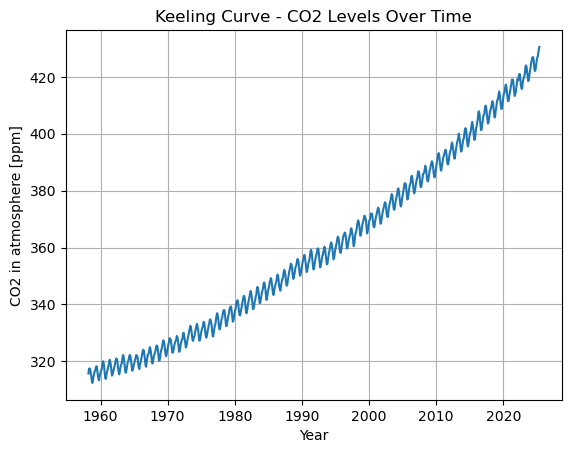

807


tensor(19.4262)

In [ ]:
# We'll only need 2 relevant columns: decimal date and average CO2
X = co2_data['decimal date'].values
y = co2_data['average'].values

# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

X_train = X_tensor
y_train = y_tensor
plt.plot(X_train.numpy(), y_train.numpy())
plt.xlabel('Year')
plt.ylabel('CO2 in atmosphere [ppm]')
plt.title('Keeling Curve - CO2 Levels Over Time')
plt.grid()
plt.show()

print(f"{len(X_train)}") # Number of training points

# Standardize the data (helps with stability and convergence of training the GP model)
X_mean, X_std = X_tensor.mean(), X_tensor.std()
y_mean, y_std = y_tensor.mean(), y_tensor.std()
X_train = (X_tensor - X_mean) / X_std
y_train = (y_tensor - y_mean) / y_std

In [24]:
# Define a GP model using GPyTorch
class CO2GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        # Using a linear mean function makes sense here, since we expect a long-term trend in the CO2 data.
        self.mean_module = gpytorch.means.LinearMean(input_size=1)

        # TODO: This is the core of the task. You need to design a composite kernel that captures the different patterns observed in the time series (think about where these could come from!), e.g.
        # 1.  A long-term, slowly increasing trend.
        # 2.  A seasonal (periodic) component.
        # 3.  A medium-term component.
        # 3.  Smaller, short-term irregularities or noise.
        # At the end, you want to combine these by adding/multiplying and/or scaling them (using gpytorch.kernels.ScaleKernel). Refer e.g. to the Kernel Cookbook, or the textbook mentioned above for inspiration. Choices here could include `RBFKernel`, `PeriodicKernel`, `MaternKernel`, `RQKernel`, and `ScaleKernel`.
        # A possible example could look like this:
        k_trend     = gpytorch.kernels.RBFKernel()
        k_seasonal  = gpytorch.kernels.PeriodicKernel() * gpytorch.kernels.RBFKernel()
        k_mid    = gpytorch.kernels.MaternKernel(nu=1.5)

        # For each kernel you define, you can also set the `outputscale` parameter (e.g. k_long.outputscale) to control the amplitude of the kernel. Choose this based on your expectations about the data. 

        self.covar_module = gpytorch.kernels.ScaleKernel(k_trend + k_seasonal + k_mid) # A sum of the kernels with an overall scaling factor
        self.covar_module.outputscale = 0.1


    def forward(self, x):
        # This defines the Prior of the GP. model(new_data) will then condition on some new data to produce the predictive posterior - GPyTorch nicely handles the posterior inference automatically for us.
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [28]:
# Initialize the model and the likelihood
likelihood = gpytorch.likelihoods.GaussianLikelihood() # This incorporates a white noise term into the model (observation noise)
model = CO2GPModel(X_train, y_train, likelihood)

def initialize_model_params(model, X_std):
    with torch.no_grad():
        kernels = model.covar_module.base_kernel.kernels

        k_trend = kernels[0]
        k_trend.lengthscale = 100.0 / X_std

        k_seasonal = kernels[1]
        periodic_kernel = k_seasonal.kernels[0]
        envelope_rbf = k_seasonal.kernels[1]

        periodic_kernel.period_length = 1.0 / X_std
        periodic_kernel.lengthscale = 0.5 / X_std
        envelope_rbf.lengthscale = 10.0 / X_std

        k_medium = kernels[2]
        k_medium.lengthscale = 3.0 / X_std

        model.likelihood.noise = 0.1


# Initialize the model using your prior knowledge
initialize_model_params(model, X_std)

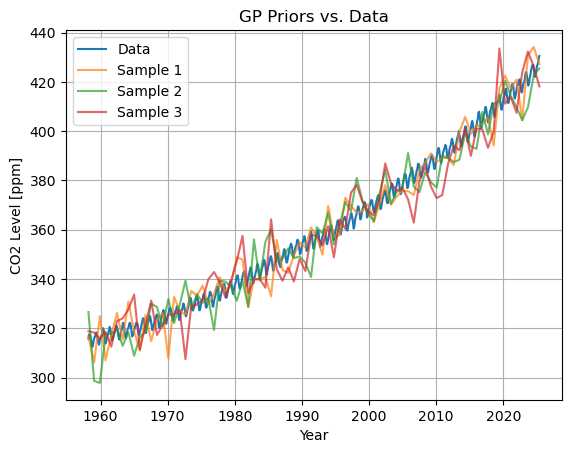

In [30]:
# You can test whether our kernel & initialization makes sense by sampling from the prior distribution a few times and comparing to the data.
model.eval()
# Create a grid for plotting priors
X_prior_plot = torch.linspace(X_train.min(), X_train.max(), 80)
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    prior_samples = model(X_prior_plot).sample(torch.Size([3]))  # Sample 3 functions from the prior, evaluated on the grid

# Un-standardize the prior samples and X coordinates for plotting in the original coordinates
prior_samples_unscaled = prior_samples * y_std + y_mean
X_prior_plot_unscaled = X_prior_plot * X_std + X_mean

# Plot the prior samples over the data
plt.plot(X_tensor.numpy(), y_tensor.numpy(),label='Data')
for i in range(prior_samples.shape[0]):
    plt.plot(X_prior_plot_unscaled.numpy(), prior_samples_unscaled[i].numpy(), label=f'Sample {i+1}',alpha=0.7)
plt.title('GP Priors vs. Data')
plt.xlabel('Year')
plt.ylabel('CO2 Level [ppm]')
plt.legend()
plt.grid()
plt.show()

Iter 25/300 - Loss: -0.179
Iter 50/300 - Loss: -0.313
Iter 75/300 - Loss: -0.474
Iter 100/300 - Loss: -0.600
Iter 125/300 - Loss: -0.743
Iter 150/300 - Loss: -0.865
Iter 175/300 - Loss: -0.992
Iter 200/300 - Loss: -1.116
Iter 225/300 - Loss: -1.218
Iter 250/300 - Loss: -1.364
Iter 275/300 - Loss: -1.486
Iter 300/300 - Loss: -1.595


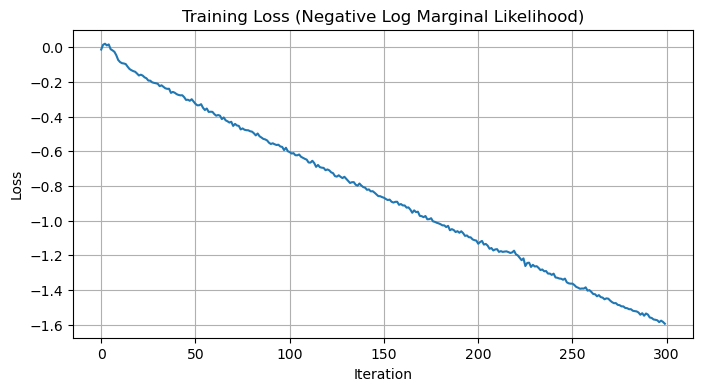

In [31]:
# For optimizing the model, put the model and likelihood in training mode
model.train()
likelihood.train()

# We'll use SGD with the Adam optimizer 
# TODO: Set a good learning rate for Adam.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# The optimization criterion is the marginal log likelihood, as described in Task 1.2
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

# Training loop 
num_epochs = 300 # adjust as needed
loss_history = []
# Optimize log marginal likelihood
for i in range(num_epochs):
    # TODO: Implement the training loop
    # 1. Zero the gradients
    # 2. Get output from model
    # 3. Calculate the loss (= negative MLL), loss = ...
    # 4. Backpropagate the loss, perform optimizer step
    optimizer.zero_grad()
    output = model(X_train)
    loss = -mll(output, y_train)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item()) # store loss values for plotting
    if (i + 1) % 25 == 0:
        print(f'Iter {i+1}/{num_epochs} - Loss: {loss.item():.3f}') # print progress


# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title('Training Loss (Negative Log Marginal Likelihood)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid()
plt.show()

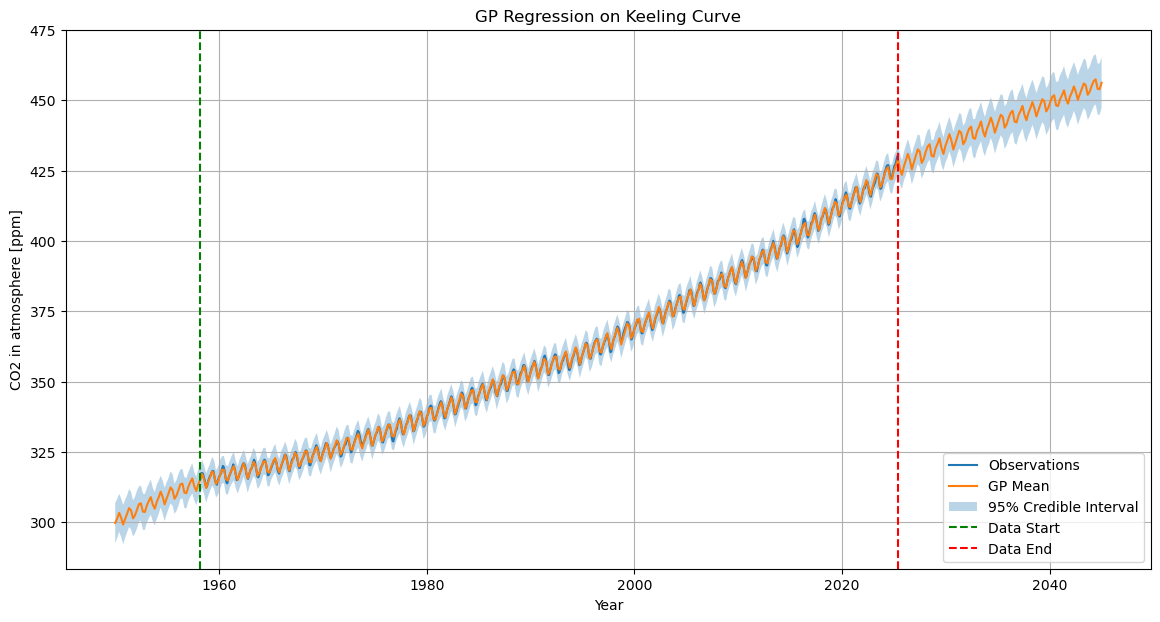

In [32]:
# Plotting results

# Put the model in evaluation mode
model.eval()
likelihood.eval()

# Create some test points, including extrapolation into the future
X_test = torch.linspace(1950, 2045, 500) # Predict from 1950 to 2045 - adjust as you like
X_test_scaled = (X_test - X_mean) / X_std

# Make predictions and get credible intervals
with torch.no_grad(), gpytorch.settings.fast_pred_var(): #fast_pred_var speeds up the predictions by using a fast approximation of the predictive variance
    predictions = likelihood(model(X_test_scaled)) # get posterior predictive distribution
    mean = predictions.mean
    lower, upper = predictions.confidence_region()

# Un-standardize the results for plotting
mean_unscaled = mean * y_std + y_mean
lower_unscaled = lower * y_std + y_mean
upper_unscaled = upper * y_std + y_mean

plt.figure(figsize=(14, 7))
# Training data
plt.plot(X, y, markersize=4, label='Observations')
# Predictive mean
plt.plot(X_test.numpy(), mean_unscaled.numpy(), label='GP Mean')
# Confidence region (95% credible interval)
plt.fill_between(X_test.numpy(), lower_unscaled.numpy(), upper_unscaled.numpy(), alpha=0.3, label='95% Credible Interval')
# Draw 2 lines where extrapolation starts
last_year = X_train.max().item()
last_year_unscaled = last_year * X_std + X_mean
first_year = X_train.min().item()
first_year_unscaled = first_year * X_std + X_mean
plt.axvline(x=first_year_unscaled, color='green', linestyle='--', label='Data Start')
plt.axvline(x=last_year_unscaled, color='red', linestyle='--', label='Data End')
plt.title('GP Regression on Keeling Curve')
plt.xlabel('Year')
plt.ylabel('CO2 in atmosphere [ppm]')
plt.legend()
plt.grid()
plt.show()

In [39]:
# TODO: Print the learned hyperparameters of your model.
# You can access those as follows:
# model.likelihood.noise.item()  # For the likelihood noise
# model.mean_module.weights.item()  # For the linear mean function slope
# model.mean_module.bias.item()  # For the linear mean function bias
# model.covar_module.base_kernel.kernels[i].lengthscale.item()  # For the lengthscale of the i-th kernel (or model.covar_module.base_kernel.kernels[i].period_length.item() for periodic kernels)
print("Learned Hyperparameters:")
print(f"Likelihood noise: {model.likelihood.noise.item():.4f}")
kernels = model.covar_module.base_kernel.kernels
k_trend = kernels[0]
print(f"trend lengthscale: {k_trend.lengthscale.item():.4f}")

k_seasonal = kernels[1]
periodic = k_seasonal.kernels[0]
envelope = k_seasonal.kernels[1]
print(f"seasonal period_length: {periodic.period_length.item():.4f}")
print(f"seasonal periodic lengthscale: {periodic.lengthscale.item():.4f}")
print(f"seasonal envelope lengthscale: {envelope.lengthscale.item():.4f}")

k_mid = kernels[2]
print(f"mid-term lengthscale: {k_mid.lengthscale.item():.4f}")

Learned Hyperparameters:
Likelihood noise: 0.0050
trend lengthscale: 4.9263
seasonal period_length: 0.0514
seasonal periodic lengthscale: 0.0964
seasonal envelope lengthscale: 1.8823
mid-term lengthscale: 0.7226


### Results Assessment
**TODO**: Given your results, assess the performance of your regression model and interpret the learned hyperparameters. Do they coincide with your expectations of the Keeling curve?

The learned $\text{CO}_2$ curve fits the Keeling curve well. The learnt parameters agree perfectly with my expectations. $\text{Xstd}\times \text{PeriodicLength}$ is close to 1(year). The learnt noise is small, which indicates the precision of Keeling's measurement.